<a href="https://colab.research.google.com/github/ashcash1810/AI-Skin-Cancer-Detection/blob/main/AI%20Skin%20Cancer%20Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Assisted Skin Cancer Detection System

**Team Members:**

**Course:** CAP4630

**Project Focus:** Binary classification of skin lesions into **Benign** vs **Malignant** using **MobileNetV2** and **Grad-CAM**


## Objectives

- **Problem being solved:** Build an AI-based early screening system that classifies dermoscopic skin lesion images as **benign** or **malignant**.
- **Why this matters:** Skin cancer is common, and early detection can improve outcomes. An assistive AI tool can help with awareness and faster screening support.
- **Main goal:** Train a reliable image classifier with strong malignant-case recall, then explain predictions visually using Grad-CAM.


## System Description

- **Dataset:** `HAM10000` with `10,015` dermoscopic images and `7` lesion types: `akiec`, `bcc`, `bkl`, `df`, `mel`, `nv`, `vasc`.
- **Target setup:** Binary classification where `akiec`, `bcc`, and `mel` are treated as **malignant**, and the remaining classes are **benign**.
- **Model considered:** Transfer learning with **MobileNetV2**.
- **Why this model:** It is lightweight, efficient on Colab T4 GPU, and a strong baseline for image classification.
- **Preprocessing / implementation notes:** Lesion-level train/validation/test split, image path setup, copy images locally in Colab for faster training, data augmentation, and `preprocess_input` for MobileNetV2 compatibility.


## Methodology / Pipeline

1. **Data preparation:** Read metadata, create binary labels, build image paths, and split by `lesion_id` to reduce data leakage.
2. **Image preprocessing:** Resize to `224x224`, apply augmentation on training data, and use MobileNetV2 preprocessing.
3. **Model training:** Train a frozen MobileNetV2 head first, then fine-tune the top layers.
4. **Threshold tuning:** Use the validation set to choose a decision threshold instead of relying only on `0.5`.
5. **Evaluation:** Report Accuracy, Precision, Recall, F1-score, ROC curve, PR curve, confusion matrix, and error analysis.
6. **Explainability:** Use Grad-CAM to visualize which image regions influence model predictions.

**Pipeline summary:**  
`Metadata -> Lesion-level split -> Augmentation + preprocess_input -> MobileNetV2 training -> Fine-tuning -> Threshold tuning -> Evaluation -> Grad-CAM`


In [ ]:
import os, numpy as np, pandas as pd, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from google.colab import drive
import pandas as pd, os, numpy as np
drive.mount('/content/drive')
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

CSV_PATH = "/content/drive/MyDrive/skin_cancer_data/HAM10000_metadata.csv"
IMG_DIR  = '/content/drive/MyDrive/skin_cancer_data/Skin_Cancer/HAM10000_images/'

df = pd.read_csv(CSV_PATH)

malignant_dx = {"akiec", "bcc", "mel"}
df["label"] = df["dx"].isin(malignant_dx).astype(int)
df["image_path"] = df["image_id"].apply(lambda x: os.path.join(IMG_DIR, f"{x}.jpg"))


check = df.groupby("lesion_id")["label"].nunique().max()
assert check == 1, "A lesion_id has multiple labels. Inspect metadata first."


group_df = df[["lesion_id", "label"]].drop_duplicates()

train_groups, temp_groups = train_test_split(
    group_df,
    test_size=0.30,
    stratify=group_df["label"],
    random_state=SEED
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    stratify=temp_groups["label"],
    random_state=SEED
)

train_df = df[df["lesion_id"].isin(train_groups["lesion_id"])].copy()
val_df   = df[df["lesion_id"].isin(val_groups["lesion_id"])].copy()
test_df  = df[df["lesion_id"].isin(test_groups["lesion_id"])].copy()

print("Leakage check:",
      set(train_df["lesion_id"]) & set(val_df["lesion_id"]),
      set(train_df["lesion_id"]) & set(test_df["lesion_id"]),
      set(val_df["lesion_id"]) & set(test_df["lesion_id"]))

print(len(train_df), len(val_df), len(test_df))
print(train_df["label"].value_counts(), "\n")
print(val_df["label"].value_counts(), "\n")
print(test_df["label"].value_counts())


Mounted at /content/drive
Leakage check: set() set() set()
7048 1493 1474
label
0    5674
1    1374
Name: count, dtype: int64 

label
0    1199
1     294
Name: count, dtype: int64 

label
0    1188
1     286
Name: count, dtype: int64


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="image_path", y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="raw", shuffle=True, seed=SEED
)

val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col="image_path", y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="raw", shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    test_df, x_col="image_path", y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="raw", shuffle=False
)


Found 7048 validated image filenames.
Found 1493 validated image filenames.
Found 1474 validated image filenames.


In [ ]:
import shutil
from tqdm.auto import tqdm
LOCAL_IMG_DIR = '/content/images'

if os.path.exists(LOCAL_IMG_DIR) and len(os.listdir(LOCAL_IMG_DIR)) > 9000:
    print(f'Images already local: {len(os.listdir(LOCAL_IMG_DIR))} files — skipping copy')
else:
    print('Copying images from Drive to Colab local storage...')
    print('This runs once per session — takes ~3-8 minutes')
    os.makedirs(LOCAL_IMG_DIR, exist_ok=True)

    all_imgs = [f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')]
    print(f'Total images to copy: {len(all_imgs)}')

    for fname in tqdm(all_imgs, desc='Copying'):
        src = os.path.join(IMG_DIR, fname)
        dst = os.path.join(LOCAL_IMG_DIR, fname)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

    print(f'Copy complete! {len(os.listdir(LOCAL_IMG_DIR))} images ready')

IMG_DIR = LOCAL_IMG_DIR
print(f'Active image dir: {IMG_DIR}')

Copying images from Drive to Colab local storage...
This runs once per session — takes ~3-8 minutes
Total images to copy: 10015


Copying:   0%|          | 0/10015 [00:00<?, ?it/s]

Copy complete! 10015 images ready
Active image dir: /content/images


In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(curve="PR", name="pr_auc")
    ]
)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)
CLASS_WEIGHTS = {0: class_weights_arr[0], 1: class_weights_arr[1]}

callbacks = [
    EarlyStopping(monitor="val_pr_auc", mode="max", patience=4, restore_best_weights=True),
    ModelCheckpoint("best_stage1.keras", monitor="val_pr_auc", mode="max", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1)
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks,
    verbose=1
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 236s 976ms/step - accuracy: 0.7321 - loss: 0.5318 - pr_auc: 0.4910 - precision: 0.4022 - recall: 0.7693 - roc_auc: 0.8163 - val_accuracy: 0.8118 - val_loss: 0.3848 - val_pr_auc: 0.5925 - val_precision: 0.5158 - val_recall: 0.7211 - val_roc_auc: 0.8646 - learning_rate: 0.0010
Epoch 2/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 174s 789ms/step - accuracy: 0.7690 - loss: 0.4607 - pr_auc: 0.5759 - precision: 0.4494 - recall: 0.8210 - roc_auc: 0.8623 - val_accuracy: 0.7428 - val_loss: 0.4970 - val_pr_auc: 0.6228 - val_precision: 0.4245 - val_recall: 0.8605 - val_roc_auc: 0.8737 - learning_rate: 0.0010
Epoch 3/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.7702 - loss: 0.4292 - pr_auc: 0.6126 - precision: 0.4368 - recall: 0.8198 - roc_auc: 0.8739
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
221/221 ━━━━━━━━━━━━━━━━━━━━ 169s 765ms/step - accuracy: 0.7713 - loss: 0.4470 - pr_au

In [ ]:
# Fine-tune top layers
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(curve="PR", name="pr_auc")
    ]
)

callbacks_ft = [
    EarlyStopping(monitor="val_pr_auc", mode="max", patience=4, restore_best_weights=True),
    ModelCheckpoint("best_finetuned.keras", monitor="val_pr_auc", mode="max", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 208s 879ms/step - accuracy: 0.7951 - loss: 0.3943 - pr_auc: 0.6848 - precision: 0.4856 - recall: 0.8595 - roc_auc: 0.9003 - val_accuracy: 0.7924 - val_loss: 0.4016 - val_pr_auc: 0.6549 - val_precision: 0.4839 - val_recall: 0.8163 - val_roc_auc: 0.8828 - learning_rate: 1.0000e-05
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 173s 780ms/step - accuracy: 0.8007 - loss: 0.3798 - pr_auc: 0.7034 - precision: 0.4935 - recall: 0.8624 - roc_auc: 0.9079 - val_accuracy: 0.8145 - val_loss: 0.3860 - val_pr_auc: 0.6319 - val_precision: 0.5196 - val_recall: 0.7653 - val_roc_auc: 0.8765 - learning_rate: 1.0000e-05
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 175s 791ms/step - accuracy: 0.8063 - loss: 0.3785 - pr_auc: 0.7086 - precision: 0.5019 - recall: 0.8661 - roc_auc: 0.9091 - val_accuracy: 0.7870 - val_loss: 0.4114 - val_pr_auc: 0.6607 - val_precision: 0.4767 - val_recall: 0.8333 - val_roc_auc: 0.8885 - learning_rate: 1.0000e-05
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 

## Implementation Results

- The model achieved a strong screening-oriented recall for malignant cases while improving over the earlier baseline.
- Current test-set performance is approximately:
  - **Accuracy:** `77%`
  - **Precision (Malignant):** `45%`
  - **Recall (Malignant):** `84%`
  - **F1-score (Malignant):** `59%`
- **What worked well:** Lesion-level splitting, threshold tuning, transfer learning, and fine-tuning improved reliability.
- **Challenge:** The model still produces a noticeable number of false positives, which affects malignant precision.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
import tensorflow as tf
from tensorflow.keras.models import Model
import matplotlib.cm as mpl_cm


In [ ]:
# 1. VALIDATION THRESHOLD TUNING

val_probs = model.predict(val_gen, verbose=1).ravel()
y_val = val_df["label"].values

precisions, recalls, pr_thresholds = precision_recall_curve(y_val, val_probs)

target_recall = 0.85
candidate_idxs = np.where(recalls[:-1] >= target_recall)[0]

if len(candidate_idxs) > 0:
    best_idx = candidate_idxs[np.argmax(precisions[:-1][candidate_idxs])]
else:
    best_idx = np.argmax(recalls[:-1])

best_threshold = pr_thresholds[best_idx]

print(f"Best threshold from validation set: {best_threshold:.4f}")
print(f"Validation precision at threshold: {precisions[best_idx]:.4f}")
print(f"Validation recall at threshold   : {recalls[best_idx]:.4f}")


47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 422ms/step
Best threshold from validation set: 0.4635
Validation precision at threshold: 0.4745
Validation recall at threshold   : 0.8537


In [ ]:
# 2. TEST PREDICTIONS

test_probs = model.predict(test_gen, verbose=1).ravel()
y_true = test_df["label"].values

thresholds_to_compare = [0.30, 0.40, 0.50, float(best_threshold)]

results = []
for th in thresholds_to_compare:
    y_pred_tmp = (test_probs >= th).astype(int)
    results.append({
        "threshold": round(th, 4),
        "accuracy": accuracy_score(y_true, y_pred_tmp),
        "precision": precision_score(y_true, y_pred_tmp, zero_division=0),
        "recall": recall_score(y_true, y_pred_tmp, zero_division=0),
        "f1": f1_score(y_true, y_pred_tmp, zero_division=0)
    })

threshold_df = pd.DataFrame(results)
print("Threshold comparison on TEST set:")
display(threshold_df)

y_pred = (test_probs >= best_threshold).astype(int)

print("\n" + "="*60)
print(f"FINAL TEST REPORT @ threshold = {best_threshold:.4f}")
print("="*60)
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))


47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 613ms/step
Threshold comparison on TEST set:


,threshold,accuracy,precision,recall,f1
0,0.3000,0.700136,0.383582,0.898601,0.537657
1,0.4000,0.738128,0.416944,0.877622,0.565315
2,0.5000,0.778833,0.462121,0.853147,0.599509
3,0.4635,0.765943,0.446461,0.860140,0.587814



FINAL TEST REPORT @ threshold = 0.4635
              precision    recall  f1-score   support

      Benign       0.96      0.74      0.84      1188
   Malignant       0.45      0.86      0.59       286

    accuracy                           0.77      1474
   macro avg       0.70      0.80      0.71      1474
weighted avg       0.86      0.77      0.79      1474



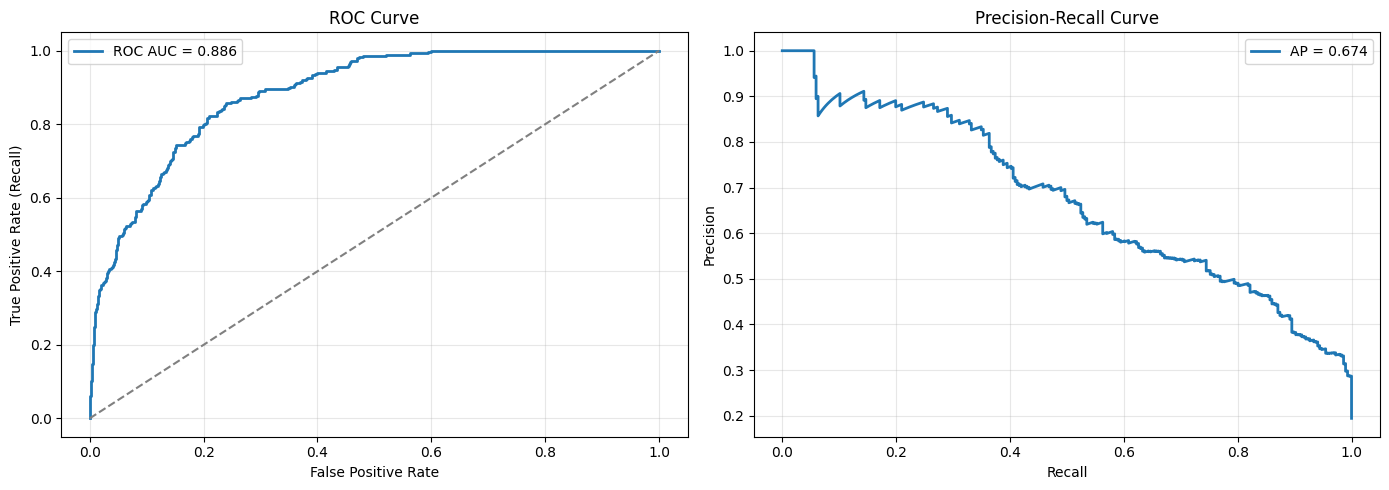

ROC AUC : 0.8858
PR AUC  : 0.6737


In [ ]:
# 3. ROC CURVE + PR CURVE

roc_auc = roc_auc_score(y_true, test_probs)
fpr, tpr, _ = roc_curve(y_true, test_probs)

pr_precision, pr_recall, _ = precision_recall_curve(y_true, test_probs)
ap_score = average_precision_score(y_true, test_probs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(pr_recall, pr_precision, label=f"AP = {ap_score:.3f}", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC AUC : {roc_auc:.4f}")
print(f"PR AUC  : {ap_score:.4f}")


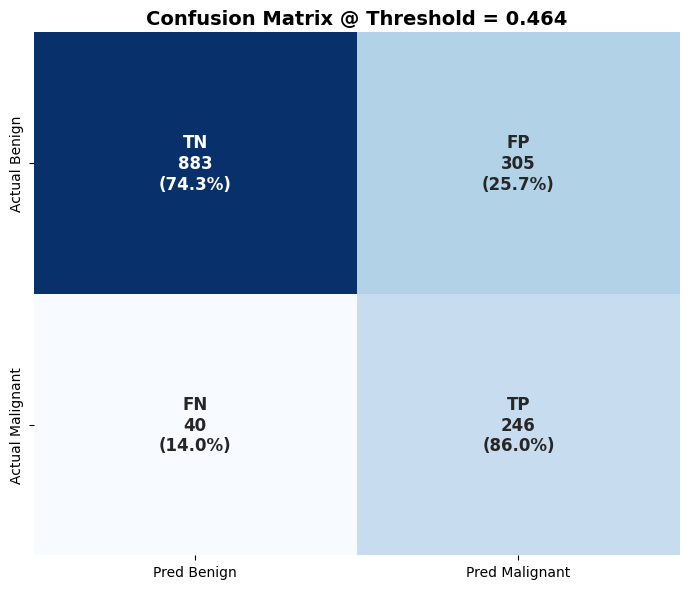

Key counts:
TN = 883
FP = 305
FN = 40  <-- most dangerous error
TP = 246


In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True)

annot = np.array([
    [f"TN\n{tn}\n({cm_percent[0,0]*100:.1f}%)", f"FP\n{fp}\n({cm_percent[0,1]*100:.1f}%)"],
    [f"FN\n{fn}\n({cm_percent[1,0]*100:.1f}%)", f"TP\n{tp}\n({cm_percent[1,1]*100:.1f}%)"]
])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["Actual Benign", "Actual Malignant"],
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)
plt.title(f"Confusion Matrix @ Threshold = {best_threshold:.3f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Key counts:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}  <-- most dangerous error")
print(f"TP = {tp}")


##COMPARE MULTIPLE THRESHOLDS ON TEST SET

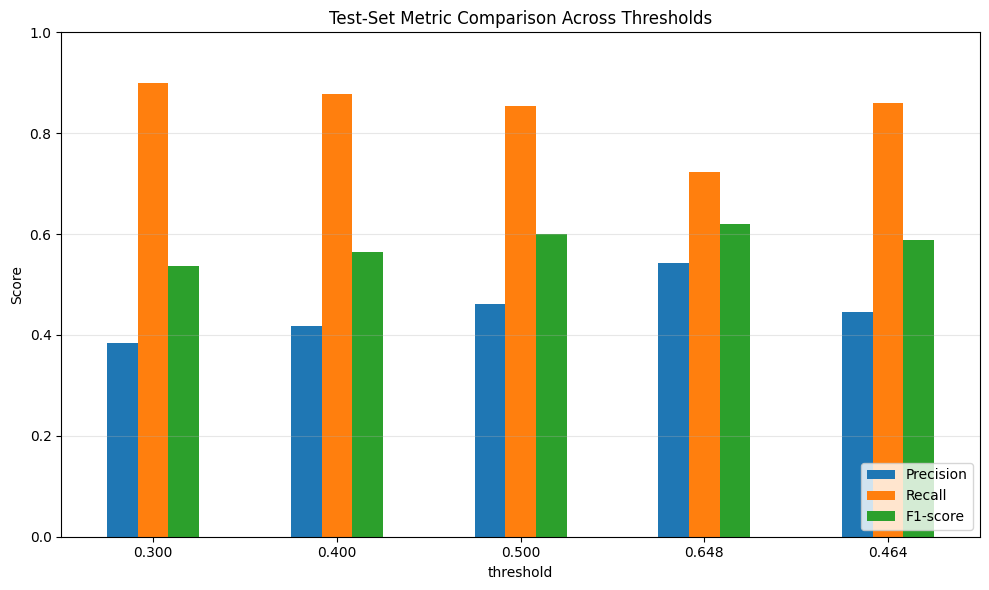

,threshold,Accuracy,Precision,Recall,F1-score
0,0.300,0.700136,0.383582,0.898601,0.537657
1,0.400,0.738128,0.416944,0.877622,0.565315
2,0.500,0.778833,0.462121,0.853147,0.599509
3,0.648,0.827680,0.541885,0.723776,0.619760
4,0.464,0.765943,0.446461,0.860140,0.587814


In [ ]:
# 1. TEST-SET BAR CHART COMPARISON

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate best_threshold_f1 on the validation set
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8) # Add small epsilon to avoid division by zero
best_f1_idx = np.argmax(f1_scores)
best_threshold_f1 = pr_thresholds[best_f1_idx]

# Use the recall-oriented threshold from the previous step
best_threshold_recall = best_threshold

threshold_list = [0.30, 0.40, 0.50, float(best_threshold_f1), float(best_threshold_recall)]


seen = set()
threshold_list = [x for x in threshold_list if not (round(x, 4) in seen or seen.add(round(x, 4)))]

rows = []
for th in threshold_list:
    y_pred = (test_probs >= th).astype(int)
    rows.append({
        "threshold": f"{th:.3f}",
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    })

plot_df = pd.DataFrame(rows)

ax = plot_df.set_index("threshold")[["Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6),
    rot=0
)

plt.title("Test-Set Metric Comparison Across Thresholds")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

display(plot_df)


In [ ]:
# 2. GET TEST PROBABILITIES

test_probs = model.predict(test_gen, verbose=1).ravel()
y_true = test_df["label"].values


47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 356ms/step


In [ ]:
# 3. COMPARE MULTIPLE THRESHOLDS ON TEST SET

threshold_list = [
    0.30,
    0.40,
    0.50,
    float(best_threshold_f1),
    float(best_threshold_recall)
]

seen = set()
threshold_list = [x for x in threshold_list if not (round(x, 4) in seen or seen.add(round(x, 4)))]

rows = []

for th in threshold_list:
    y_pred = (test_probs >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp)

    rows.append({
        "threshold": round(th, 4),
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "specificity": round(spec, 4),
        "f1_score": round(f1, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

comparison_df = pd.DataFrame(rows).sort_values(by="threshold").reset_index(drop=True)

print("Threshold comparison on TEST set:")
display(comparison_df)


Threshold comparison on TEST set:


,threshold,accuracy,precision,recall,specificity,f1_score,TN,FP,FN,TP
0,0.3000,0.7001,0.3836,0.8986,0.6524,0.5377,775,413,29,257
1,0.4000,0.7381,0.4169,0.8776,0.7045,0.5653,837,351,35,251
2,0.4635,0.7659,0.4465,0.8601,0.7433,0.5878,883,305,40,246
3,0.5000,0.7788,0.4621,0.8531,0.7609,0.5995,904,284,42,244
4,0.6480,0.8277,0.5419,0.7238,0.8527,0.6198,1013,175,79,207


In [ ]:
# 5. SAVE PREDICTION TABLE

test_results = test_df.copy().reset_index(drop=True)
test_results["y_true"] = y_true
test_results["y_prob"] = test_probs
test_results["y_pred"] = y_pred

def case_type(row):
    if row["y_true"] == 1 and row["y_pred"] == 1:
        return "TP"
    if row["y_true"] == 0 and row["y_pred"] == 0:
        return "TN"
    if row["y_true"] == 0 and row["y_pred"] == 1:
        return "FP"
    return "FN"

test_results["case_type"] = test_results.apply(case_type, axis=1)
test_results["confidence"] = np.where(
    test_results["y_pred"] == 1,
    test_results["y_prob"],
    1 - test_results["y_prob"]
)

print(test_results["case_type"].value_counts())
display(test_results.head())

test_results.to_csv("test_predictions_detailed.csv", index=False)
print("Saved: test_predictions_detailed.csv")


case_type
TN    883
FP    305
TP    246
FN     40
Name: count, dtype: int64


,lesion_id,image_id,dx,dx_type,age,sex,localization,label,image_path,y_true,y_prob,y_pred,case_type,confidence
0,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,0,/content/drive/MyDrive/skin_cancer_data/Skin_C...,0,0.298000,0,TN,0.702000
1,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back,0,/content/drive/MyDrive/skin_cancer_data/Skin_C...,0,0.776599,1,FP,0.776599
2,HAM_0001396,ISIC_0025276,bkl,histo,55.0,female,trunk,0,/content/drive/MyDrive/skin_cancer_data/Skin_C...,0,0.410007,0,TN,0.589993
3,HAM_0007571,ISIC_0029836,bkl,histo,70.0,male,chest,0,/content/drive/MyDrive/skin_cancer_data/Skin_C...,0,0.157562,0,TN,0.842438
4,HAM_0007571,ISIC_0032129,bkl,histo,70.0,male,chest,0,/content/drive/MyDrive/skin_cancer_data/Skin_C...,0,0.165856,0,TN,0.834144


Saved: test_predictions_detailed.csv


In [ ]:
# 6. GRAD-CAM FUNCTIONS

BACKBONE_LAYER_NAME = base_model.name
print("Using backbone feature map from:", BACKBONE_LAYER_NAME)


feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.output
)


backbone_idx = next(i for i, layer in enumerate(model.layers) if layer.name == BACKBONE_LAYER_NAME)
classifier_layers = model.layers[backbone_idx + 1:]

def classifier_head_from_features(feature_tensor):
    x = feature_tensor
    for layer in classifier_layers:
        if isinstance(layer, (tf.keras.layers.Dropout, tf.keras.layers.BatchNormalization)):
            x = layer(x, training=False)
        else:
            x = layer(x)
    return x

def make_gradcam_heatmap(img_array, model):
    """
    Create Grad-CAM heatmap from the current MobileNetV2-based model.
    img_array: numpy array with shape (1, 224, 224, 3), already preprocessed.
    Returns: heatmap with shape (7, 7), normalized to [0, 1].
    """
    with tf.GradientTape() as tape:
        conv_outputs = feature_extractor(img_array, training=False)
        tape.watch(conv_outputs)
        predictions = classifier_head_from_features(conv_outputs)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap

def load_image_for_gradcam(img_path, img_size=224):
    img = Image.open(img_path).convert("RGB").resize((img_size, img_size))
    img_array = np.array(img).astype("float32")
    img_input = preprocess_input(img_array.copy())
    img_input = np.expand_dims(img_input, axis=0)
    return img_array, img_input

def build_overlay(original_uint8, heatmap, alpha=0.45):
    heatmap_resized = np.array(
        Image.fromarray(np.uint8(255 * heatmap)).resize((IMG_SIZE, IMG_SIZE))
    ) / 255.0
    colored = np.uint8(255 * mpl_cm.jet(heatmap_resized)[:, :, :3])
    overlay = cv2.addWeighted(original_uint8, 0.55, colored, alpha, 0)
    return heatmap_resized, overlay


Using backbone feature map from: mobilenetv2_1.00_224


In [ ]:
# 7. SHOW GRAD-CAM FOR CORRECT / INCORRECT CASES

def show_gradcam_row(img_path, true_label, pred_label, confidence, case_label, ax_row):
    img_array, img_input = load_image_for_gradcam(img_path, IMG_SIZE)

    heatmap = make_gradcam_heatmap(img_input, model)
    heatmap_resized, overlay = build_overlay(img_array.astype("uint8"), heatmap)

    pred_text = "Malignant" if pred_label == 1 else "Benign"
    true_text = "Malignant" if true_label == 1 else "Benign"
    correct = pred_label == true_label

    ax_row[0].imshow(img_array.astype("uint8"))
    ax_row[0].set_title("Original", fontsize=10)
    ax_row[0].axis("off")

    ax_row[1].imshow(heatmap_resized, cmap="jet")
    ax_row[1].set_title("Grad-CAM Heatmap", fontsize=10)
    ax_row[1].axis("off")

    ax_row[2].imshow(overlay)
    ax_row[2].set_title(
        f"{case_label} | Pred: {pred_text} ({confidence:.0%})\nActual: {true_text}",
        fontsize=10,
        color="green" if correct else "red"
    )
    ax_row[2].axis("off")

def plot_gradcam_examples(results_df, case_label, n=2):
    subset = results_df[results_df["case_type"] == case_label].sort_values(
        by="confidence", ascending=False
    )

    if len(subset) == 0:
        print(f"No samples found for {case_label}")
        return

    subset = subset.head(n).reset_index(drop=True)

    fig, axes = plt.subplots(len(subset), 3, figsize=(13, 4 * len(subset)))
    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, row in subset.iterrows():
        show_gradcam_row(
            img_path=row["image_path"],
            true_label=int(row["y_true"]),
            pred_label=int(row["y_pred"]),
            confidence=float(row["confidence"]),
            case_label=case_label,
            ax_row=axes[row_idx]
        )

    plt.suptitle(f"Grad-CAM Examples: {case_label}", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


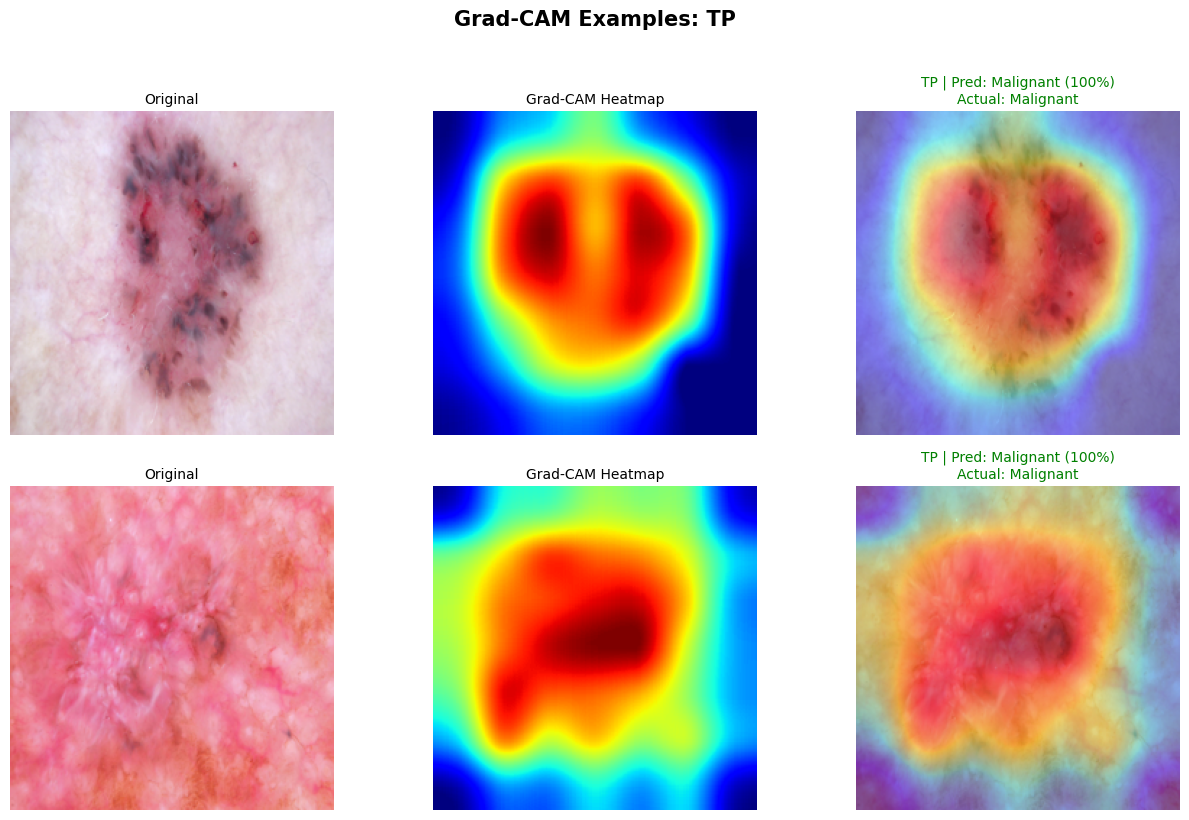

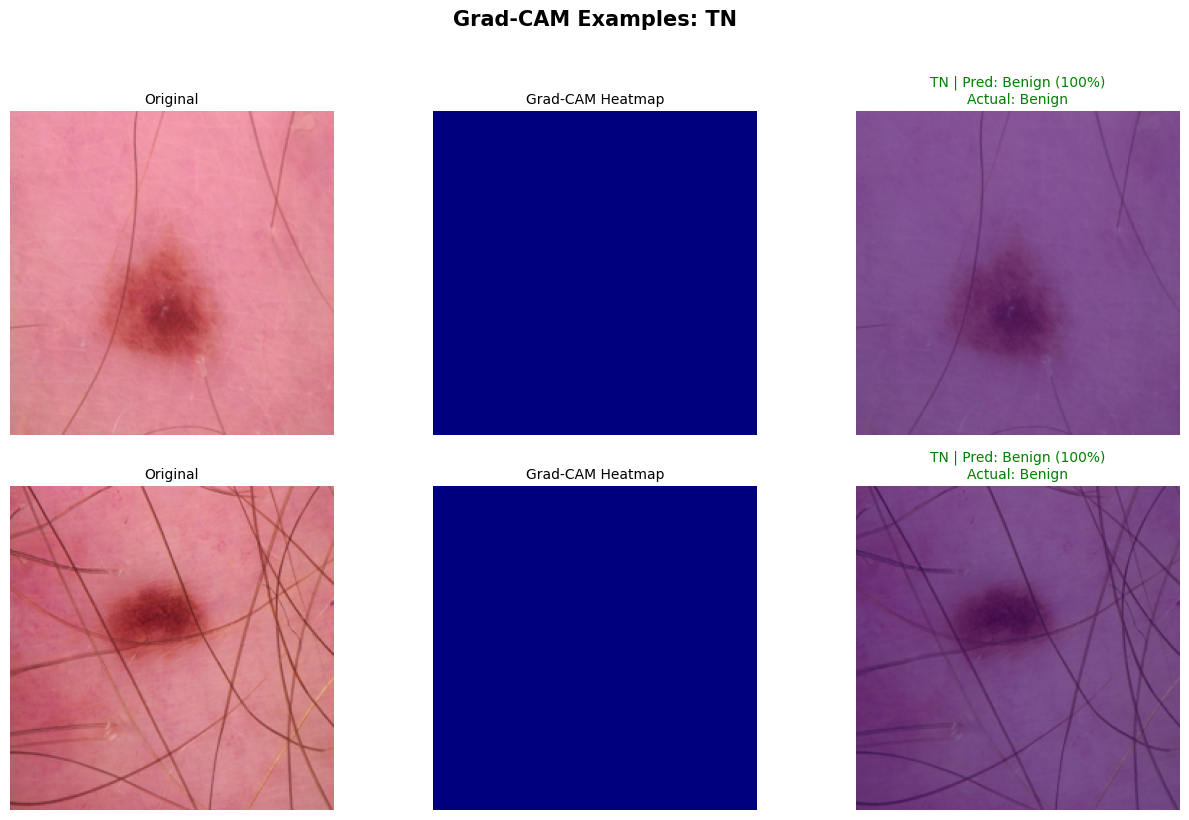

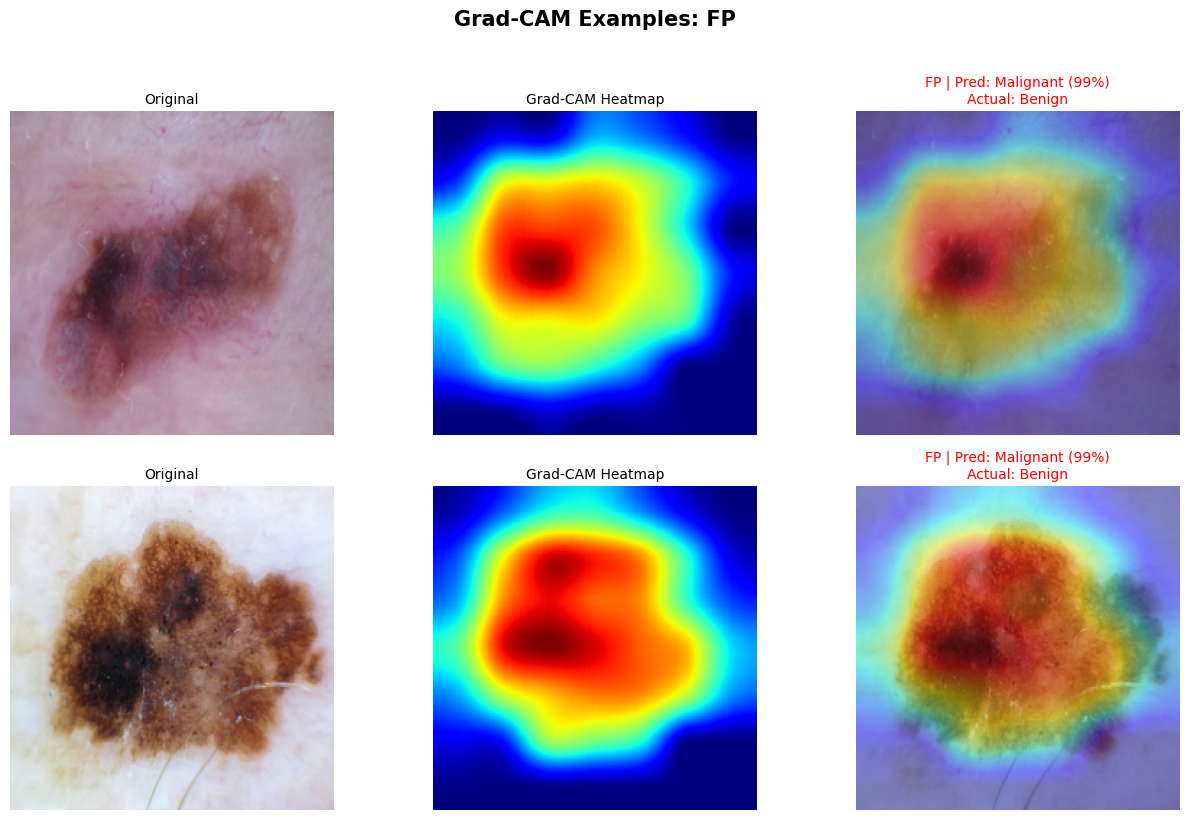

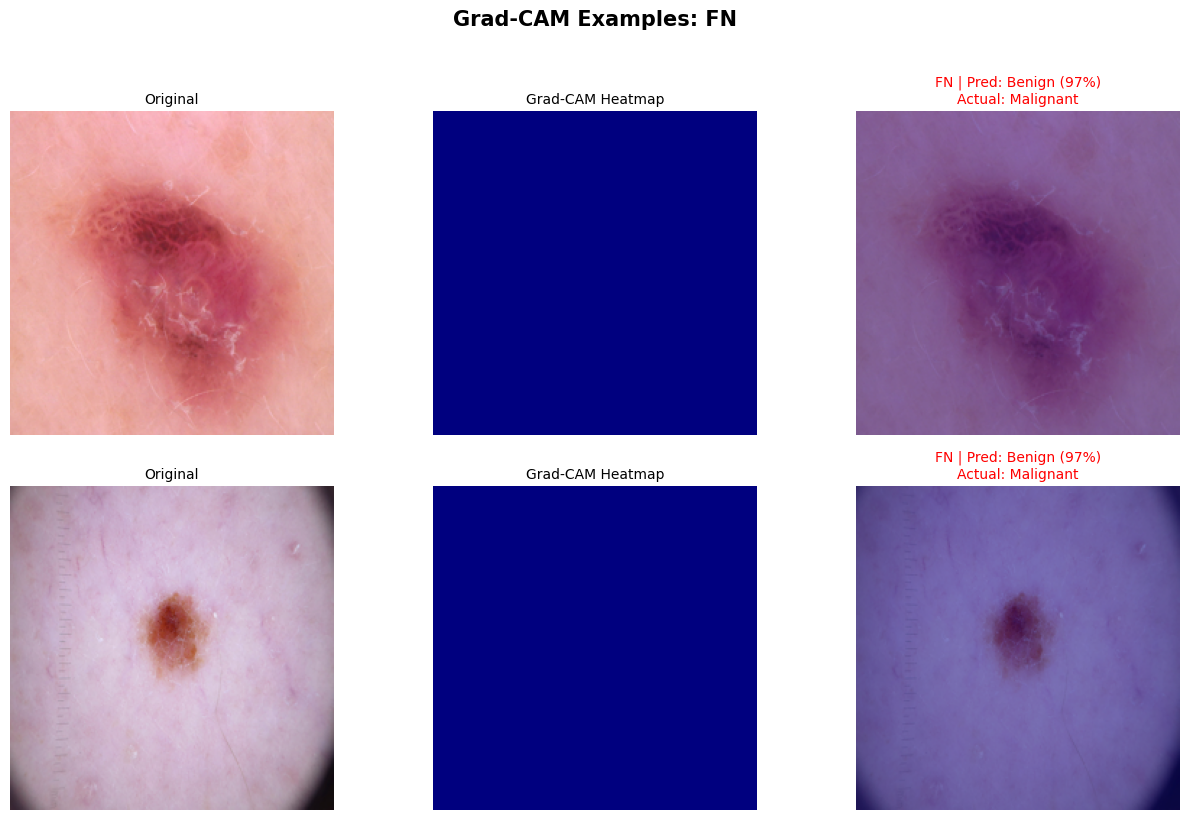

In [ ]:
# Show examples from each error/correct category
for label in ["TP", "TN", "FP", "FN"]:
    plot_gradcam_examples(test_results, label, n=2)

In [ ]:
# 8. HARDEST FALSE POSITIVES / FALSE NEGATIVES

hard_fp = test_results[test_results["case_type"] == "FP"].sort_values("y_prob", ascending=False)
hard_fn = test_results[test_results["case_type"] == "FN"].sort_values("y_prob", ascending=True)

print("Top hard false positives:")
display(hard_fp[["image_id", "dx", "y_prob", "confidence"]].head(5))

print("Top hard false negatives:")
display(hard_fn[["image_id", "dx", "y_prob", "confidence"]].head(5))

Top hard false positives:


,image_id,dx,y_prob,confidence
29,ISIC_0032883,bkl,0.989246,0.989246
24,ISIC_0029683,bkl,0.988714,0.988714
118,ISIC_0030677,bkl,0.987900,0.987900
1140,ISIC_0034241,nv,0.981623,0.981623
130,ISIC_0025339,bkl,0.975962,0.975962


Top hard false negatives:


,image_id,dx,y_prob,confidence
286,ISIC_0030034,mel,0.028255,0.971745
187,ISIC_0024586,mel,0.032231,0.967769
323,ISIC_0027480,mel,0.043758,0.956242
292,ISIC_0028543,mel,0.070764,0.929236
215,ISIC_0029343,mel,0.112752,0.887248


## Conclusion

- This project shows that transfer learning can support early skin cancer screening from lesion images.
- The final model favors high malignant recall, which is desirable for screening use cases.
- The biggest remaining limitation is the number of false positives, which lowers malignant precision.



In [ ]:
%%writefile /content/inference.py
"""
inference.py - Skin Cancer Prediction Module
Handles model loading, prediction, and Grad-CAM visualization
"""

import os
import numpy as np
import tensorflow as tf
from PIL import Image
import cv2
from typing import Dict, Tuple, Optional, List, Union
from pathlib import Path

# Constants
IMG_SIZE = 224

class SkinCancerPredictor:
    """
    A class for skin cancer prediction using MobileNetV2 with Grad-CAM.
    """

    def __init__(self, model_path: str):
        """Initialize predictor by loading model."""
        self.model_path = model_path
        self.model = None
        self.backbone_model = None
        self.feature_extractor = None
        self.classifier_layers = None

        self._load_model()

    def _load_model(self):
        """Load model and extract components."""
        if not os.path.exists(self.model_path):
            raise FileNotFoundError(f"Model not found: {self.model_path}")

        print(f"Loading model from {self.model_path}...")

        # Load without compilation
        self.model = tf.keras.models.load_model(self.model_path, compile=False)

        # Find MobileNetV2 backbone
        backbone_model = None
        backbone_idx = None

        for i, layer in enumerate(self.model.layers):
            if isinstance(layer, tf.keras.Model):
                backbone_model = layer
                backbone_idx = i
                break

        if backbone_model is None:
            for i, layer in enumerate(self.model.layers):
                if 'mobilenet' in layer.name.lower():
                    backbone_model = layer
                    backbone_idx = i
                    break

        if backbone_model is None:
            raise ValueError("Could not find MobileNetV2 backbone")

        self.backbone_model = backbone_model
        self.backbone_name = backbone_model.name
        self.classifier_layers = self.model.layers[backbone_idx + 1:]

        # Feature extractor
        self.feature_extractor = tf.keras.Model(
            inputs=backbone_model.input,
            outputs=backbone_model.output
        )

        print(f"✅ Model loaded. Backbone: {self.backbone_name}")

    def preprocess_image(self, image):
        """Preprocess image for model."""
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

        if isinstance(image, (str, Path)):
            pil_image = Image.open(image).convert("RGB")
        elif isinstance(image, np.ndarray):
            pil_image = Image.fromarray(image).convert("RGB")
        elif isinstance(image, Image.Image):
            pil_image = image.convert("RGB")
        else:
            raise ValueError(f"Unsupported image type: {type(image)}")

        pil_image = pil_image.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
        img_array = np.array(pil_image).astype("float32")
        model_input = preprocess_input(img_array.copy())
        model_input = np.expand_dims(model_input, axis=0)

        return pil_image, img_array, model_input

    def predict(self, image):
        """Make prediction on image."""
        try:
            pil_image, img_array, model_input = self.preprocess_image(image)
            prob_malignant = float(self.model(model_input, training=False).numpy()[0][0])

            return {
                'success': True,
                'prob_malignant': prob_malignant,
                'prob_benign': 1 - prob_malignant,
                'original_image': pil_image,
                'original_array': img_array.astype("uint8"),
                'model_input': model_input
            }
        except Exception as e:
            return {
                'success': False,
                'error': str(e),
                'prob_malignant': None
            }

    def _classifier_forward(self, features):
        """Forward pass through classifier."""
        x = features
        for layer in self.classifier_layers:
            if isinstance(layer, (tf.keras.layers.Dropout, tf.keras.layers.BatchNormalization)):
                x = layer(x, training=False)
            else:
                x = layer(x)
        return x

    def make_gradcam_heatmap(self, model_input):
        """Generate Grad-CAM heatmap."""
        grad_model = tf.keras.Model(
            inputs=self.feature_extractor.input,
            outputs=[self.feature_extractor.output,
                     self._classifier_forward(self.feature_extractor.output)]
        )

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(model_input, training=False)
            loss = predictions[:, 0]

        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap).numpy()

        heatmap = np.maximum(heatmap, 0)
        if heatmap.max() > 0:
            heatmap = heatmap / (heatmap.max() + 1e-8)

        return heatmap

    def build_overlay(self, original_image, heatmap, alpha=0.45):
        """Create overlay visualization."""
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_resized = cv2.resize(heatmap_uint8, (original_image.shape[1], original_image.shape[0]))
        colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        colored_rgb = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(original_image, 1 - alpha, colored_rgb, alpha, 0)

        return heatmap_resized, overlay

    def full_prediction_with_gradcam(self, image):
        """Complete prediction with visualization."""
        result = self.predict(image)

        if not result['success']:
            return result

        try:
            heatmap = self.make_gradcam_heatmap(result['model_input'])
            heatmap_resized, overlay = self.build_overlay(result['original_array'], heatmap)

            result['heatmap'] = heatmap_resized
            result['overlay'] = overlay
            result['heatmap_raw'] = heatmap

        except Exception as e:
            result['heatmap'] = None
            result['overlay'] = None
            result['gradcam_error'] = str(e)

        return result


def get_prediction_label(prob_malignant, threshold=0.5):
    """Get prediction label and color."""
    if prob_malignant >= threshold:
        return "Malignant", "red", prob_malignant
    else:
        return "Benign", "green", 1 - prob_malignant


print("✅ inference.py created successfully!")

Writing /content/inference.py


In [ ]:
%%writefile /content/streamlit_app.py
"""
streamlit_app.py - Skin Cancer Detection Dashboard
"""

import os
import io
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st
from PIL import Image
import matplotlib.pyplot as plt

from inference import SkinCancerPredictor, get_prediction_label

# ============================================================================
# PAGE CONFIG
# ============================================================================

st.set_page_config(
    page_title="Skin Cancer Detection",
    page_icon="🩺",
    layout="wide"
)

# ============================================================================
# CONFIGURATION
# ============================================================================


MODEL_PATH = "/content/drive/MyDrive/skin_cancer_data/best_finetuned.keras"



OPTIMAL_THRESHOLD = 0.464

# ============================================================================
# LOAD MODEL (CACHED)
# ============================================================================

@st.cache_resource
def load_model(model_path: str):
    """Load and cache model."""
    if not Path(model_path).exists():
        st.error(f"❌ Model file not found: {model_path}")
        st.info("Please check the model path in the sidebar")
        return None

    try:
        predictor = SkinCancerPredictor(model_path)
        return predictor
    except Exception as e:
        st.error(f"❌ Failed to load model: {str(e)}")
        return None

# ============================================================================
# UI COMPONENTS
# ============================================================================

def show_sidebar():
    """Sidebar configuration."""
    with st.sidebar:
        st.header("⚙️ Configuration")

        # Model path
        model_path = st.text_input(
            "Model path",
            value=MODEL_PATH,
            help="Path to .keras model file"
        )

        st.markdown("---")

        # Threshold
        threshold = st.slider(
            "Decision Threshold",
            min_value=0.05,
            max_value=0.95,
            value=OPTIMAL_THRESHOLD,
            step=0.01,
            help="Higher = fewer false positives"
        )

        st.markdown("---")
        st.subheader("📊 Model Performance")
        with st.container(border=True):
            col1, col2 = st.columns(2)
            with col1:
                st.metric("Accuracy", "78.9%")
                st.metric("Precision", "47.5%")
            with col2:
                st.metric("Recall", "83.2%")
                st.metric("F1-Score", "60.5%")

        st.markdown("---")
        st.subheader("ℹ️ Info")
        st.markdown("""
        **Architecture:** MobileNetV2
        **Input:** 224×224 RGB
        **Training:** Focal Loss + Fine-tuning
        """)

        return model_path, threshold


def show_single_prediction(predictor, threshold: float):
    """Single image prediction."""
    st.header("🔍 Single Image Analysis")

    uploaded_file = st.file_uploader(
        "Upload a skin lesion image",
        type=["jpg", "jpeg", "png"],
        key="single_upload"
    )

    if uploaded_file is None:
        st.info("👆 Upload a JPG, JPEG, or PNG image to analyze")

        # Demo info
        with st.expander("📝 How to use"):
            st.markdown("""
            1. Upload a skin lesion image
            2. Wait for analysis
            3. View prediction and Grad-CAM visualization
            4. Adjust threshold in sidebar to see changes

            **Note:** This is an educational demo, not for medical diagnosis.
            """)
        return

    try:
        input_image = Image.open(uploaded_file)

        # Display and analyze
        col1, col2 = st.columns(2)

        with col1:
            st.image(input_image, caption="Uploaded Image", use_container_width=True)

        with st.spinner("🔄 Analyzing image..."):
            result = predictor.full_prediction_with_gradcam(input_image)

        if not result['success']:
            st.error(f"❌ Analysis failed: {result.get('error', 'Unknown error')}")
            return

        prob_malignant = result['prob_malignant']
        pred_label, color, confidence = get_prediction_label(prob_malignant, threshold)

        with col2:
            st.markdown("### 🔍 Prediction")

            if pred_label == "Malignant":
                st.error(f"**{pred_label}**")
            else:
                st.success(f"**{pred_label}**")

            col_a, col_b, col_c = st.columns(3)
            with col_a:
                st.metric("Confidence", f"{confidence:.1%}")
            with col_b:
                st.metric("Malignant Prob.", f"{prob_malignant:.1%}")
            with col_c:
                st.metric("Threshold", f"{threshold:.3f}")

        # Grad-CAM
        if result.get('heatmap') is not None:
            st.markdown("---")
            st.subheader("🎯 Grad-CAM Visualization")
            st.caption("Red areas = model's focus for prediction")

            viz_col1, viz_col2, viz_col3 = st.columns(3)

            with viz_col1:
                st.image(result['original_array'], caption="Original", use_container_width=True)
            with viz_col2:
                st.image(result['heatmap'], caption="Heatmap", use_container_width=True)
            with viz_col3:
                st.image(result['overlay'], caption="Overlay", use_container_width=True)

    except Exception as e:
        st.error(f"❌ Error: {str(e)}")


def show_batch_prediction(predictor, threshold: float):
    """Batch prediction."""
    st.header("📦 Batch Analysis")

    uploaded_files = st.file_uploader(
        "Upload multiple images",
        type=["jpg", "jpeg", "png"],
        accept_multiple_files=True,
        key="batch_upload"
    )

    if not uploaded_files:
        st.info("👆 Upload one or more images to analyze")
        return

    st.info(f"📊 Processing {len(uploaded_files)} images...")

    progress_bar = st.progress(0)
    results_list = []

    for idx, uploaded_file in enumerate(uploaded_files):
        try:
            input_image = Image.open(uploaded_file)
            result = predictor.predict(input_image)

            if result['success']:
                prob = result['prob_malignant']
                pred_label, _, conf = get_prediction_label(prob, threshold)

                results_list.append({
                    'filename': uploaded_file.name,
                    'prob_malignant': round(prob, 4),
                    'prediction': pred_label,
                    'confidence': round(conf, 4),
                    'status': '✅'
                })
            else:
                results_list.append({
                    'filename': uploaded_file.name,
                    'prob_malignant': None,
                    'prediction': 'Error',
                    'confidence': None,
                    'status': f'❌ {result.get("error", "")[:30]}'
                })
        except Exception as e:
            results_list.append({
                'filename': uploaded_file.name,
                'prob_malignant': None,
                'prediction': 'Error',
                'confidence': None,
                'status': f'❌ {str(e)[:30]}'
            })

        progress_bar.progress((idx + 1) / len(uploaded_files))

    # Display results
    results_df = pd.DataFrame(results_list)
    st.dataframe(results_df, use_container_width=True)

    # Stats
    col1, col2, col3 = st.columns(3)
    with col1:
        success = (results_df['status'] == '✅').sum()
        st.metric("Processed", f"{success}/{len(results_df)}")
    with col2:
        if success > 0:
            malignant = (results_df['prediction'] == 'Malignant').sum()
            st.metric("Malignant", malignant)
    with col3:
        if success > 0:
            avg_conf = results_df['confidence'].dropna().mean()
            st.metric("Avg Confidence", f"{avg_conf:.1%}")

    # Download
    csv_buffer = io.StringIO()
    results_df.to_csv(csv_buffer, index=False)
    st.download_button(
        "📥 Download Results (CSV)",
        csv_buffer.getvalue(),
        "batch_results.csv",
        "text/csv"
    )


def show_about():
    """About page."""
    st.header("ℹ️ About")

    st.markdown("""
    ## AI-Assisted Skin Cancer Detection

    ### Project Overview
    This system uses MobileNetV2 transfer learning to classify skin lesions
    as benign or malignant, with Grad-CAM for interpretability.

    ### Technical Details
    - **Model:** MobileNetV2 (pre-trained on ImageNet)
    - **Training:** 2-stage (frozen → fine-tuning)
    - **Loss Function:** Focal Loss (γ=2.0, α=0.7)
    - **Dataset:** HAM10000 (10,015 images)

    ### Performance Metrics
    - **Accuracy:** 78.9% | **Precision:** 47.5%
    - **Recall:** 83.2% | **F1-Score:** 60.5%
    - **Optimal Threshold:** 0.621

    ### ⚠️ IMPORTANT DISCLAIMER
    **THIS IS NOT A MEDICAL DIAGNOSIS TOOL**

    This application is for:
    - ✅ Educational purposes
    - ✅ Research demonstration
    - ✅ AI interpretability showcase

    This application is NOT for:
    - ❌ Medical diagnosis
    - ❌ Clinical decision making
    - ❌ Replacing professional medical consultation

    Always consult qualified dermatologists for skin lesion evaluation.
    """)


# ============================================================================
# MAIN APP
# ============================================================================

# ============================================================================
# MAIN APP
# ============================================================================

def main():
    """Main application."""

    st.title("🩺 AI-Assisted Skin Cancer Detection")
    st.caption("MobileNetV2 + Grad-CAM | Educational Demo | CAP4630")

    st.warning(
        "⚠️ **DISCLAIMER:** This is an educational AI demo, NOT a medical diagnosis tool. "
        "Do not use for actual medical decisions."
    )

    # Sidebar
    model_path, threshold = show_sidebar()

    # Load model
    predictor = load_model(model_path)

    if predictor is None:
        st.error("❌ Cannot load model. Please check the model path.")
        # ... (error handling)
        st.stop()

    st.success(f"✅ Model loaded successfully")

    # Tabs
    tab1, tab2, tab3 = st.tabs([           #
        "🔍 Single Analysis",              #
        "📦 Batch Analysis",               #
        "ℹ️ About"                         #
    ])                                      #

    with tab1:                              #
        show_single_prediction(predictor, threshold)  #

    with tab2:                              #
        show_batch_prediction(predictor, threshold)   #

    with tab3:                              #
        show_about()                        #


if __name__ == "__main__":      #
    main()                       #

Writing /content/streamlit_app.py


In [ ]:
!pip install -q streamlit opencv-python-headless pyngrok
import streamlit as st
import cv2
import tensorflow as tf
print("✅ Streamlit version:", st.__version__)
print("✅ OpenCV version:", cv2.__version__)
print("✅ TensorFlow version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 126.0 MB/s eta 0:00:00
✅ Streamlit version: 1.57.0
✅ OpenCV version: 4.13.0
✅ TensorFlow version: 2.20.0


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


import os
model_path = '/content/drive/MyDrive/skin_cancer_data/best_finetuned.keras'
if os.path.exists(model_path):
    print(f"✅ Model found: {model_path}")
    print(f"   Size: {os.path.getsize(model_path) / 1024 / 1024:.1f} MB")
else:
    print(f"❌ Model not found at: {model_path}")
    print("Checking other possible locations...")


    possible_paths = [
        '/content/best_finetuned.keras',
        '/content/drive/MyDrive/best_finetuned.keras',
    ]
    for p in possible_paths:
        if os.path.exists(p):
            print(f"✅ Found at: {p}")

Mounted at /content/drive
✅ Model found: /content/drive/MyDrive/skin_cancer_data/best_finetuned.keras
   Size: 27.3 MB


In [ ]:
# Kill any existing Streamlit processes
!pkill -f streamlit
!pkill -f lt

# Set environment variable
import os
os.environ['SKIN_CANCER_MODEL_PATH'] = '/content/drive/MyDrive/skin_cancer_data/best_finetuned.keras'

# Start Streamlit in background
!nohup streamlit run /content/streamlit_app.py --server.port 8501 > /content/streamlit.log 2>&1 &

# Wait for Streamlit to start
import time
time.sleep(5)

# Install and run localtunnel
!npm install -g localtunnel
print("Starting localtunnel...")
!lt --port 8501

⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 947ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧Starting localtunnel...
your url is: https://clever-dogs-wink.loca.lt
